# From Foundational Math to SOTA: A Comparative Study of Architectural Evolution in Satellite Imagery Classification

## Part Three: Implementing a State-Of-The-Art model based on EfficientNetB0 pretrained model to reach the maximum accuracy possible on the EuroSAT dataset

--------------------------------------------------------


# Introduction: 

### I am doing this project as part of my learning journey in deep learning. Currently, I am taking the Deep Learning Specialization by Deeplearning.AI, and I decided to do this project to make my understanding of the concepts concrete and to improve my overall skills in this lovely path of AI.

### This project is part of the comparative study of from-scratch Neural Networks to SOTA on EuroSAT Classification. In this project, I am creating a SOTA model to classify the Eurosat (RGB) dataset, consisting of 10 classes.

### The architecture of the SOTA model is designed wisely to ensure that the gradients are healthy from the beginning to the end of the training process. The architecture is built in following sequence: EfficientNetB0 Backbone (pretrained on ImageNet, top 50% unfrozen for fine-tuning) → Global Average Pooling → Dense(256, ReLU) → Dropout(0.4) → Dense(10, Softmax)  

## Choosing The pretrained model:

** Note: EfficientNet models (B0 through B7) all use the same architecture design, they just scale up together in three dimensions: depth (more layers), width (more channels), and resolution (larger input). B0 is the smallest and B7 is the largest. **

### The most tedious question that comes to mind when building a pretrained model is which pretrained model should be used. As for this project, I have chosen to use the EffecientNetB0 model based on but not exclusive to these following reasons:

1. Compared to the rest of the EfficientNet lineup, B0 is the smallest one. This works well with the size of the EuroSAT dataset compared to the model capacity. EuroSAT has 27,000 images across 10 classes. B0 has 5.3 million parameters. B0's smaller capacity matches the dataset size much better comparted to other EfficientNet models.

2. B0’s leaner architecture prioritizes low-level features (edges and textures) that translate effectively from ImageNet to aerial domains, achieving 96–98% accuracy without the overfitting risks of larger models.

3. Training 10x faster than B7 on Kaggle allows for rapid hyperparameter tuning and experimentation, which is far more impactful for final performance than the marginal 0.5–1% gain of heavier models.

---




![Eurosat dataset classification example](https://miro.medium.com/v2/resize:fit:610/1*i5CK72qCucbH6ots5op86w.jpeg)

## The dataset that I am using is the EuroSAT dataset.
### I will be working on the RGB version where there are 10 classes to be classified:

1. AnnualCrop
2. Forest
3. HerbaceousVegatation
4. Highway
5. Industrial
6. Pasture
7. PermanentCrop
8. Residential
9. River
10. SeaLake

**The dataset is being used for classifying the use of land in geospatial images. Each image in the dataset is 64x64 pixels with a Ground Sampling Distance of 10m. They were all collected from the Sentinel-2 satellite.**

**I am using a ready-to-use split & shuffled version of the dataset (total of 27000 examples). The dataset is split into:**
* train.csv ---> 18900 examples
* validation.csv ---> 5400 examples
* test.csv ---> 2700 examples

**Making the split a 70/20/10 split for the train/validation/test respectively.**

[![SOTA-model-arch.jpg](https://i.postimg.cc/TYkJyKsR/SOTA-model-arch.jpg)](https://postimg.cc/w7mmZjHP)

## How did I approach the project?

The first thing that I started with after choosing the EfficientNetB0 model is defining the data preparation pipeline. After reading the CSV files with pandas, I defined the parse_image (which does three things: read the raw data, decodes the raw data into 3 channel RGB image, resizes the image to 224 * 224 to match the default pretrained model's image size) function to return the image along its label, then I used from_tensor_slices to slice the dataset into indivdual image and label pairs. Then, I used the trio of tensorflow data pipeline, the .map method that calls the parse_image function on each pair, the .batch method that divides the data to a given batch size (shuffling when training is true to create different batches everytime), the .prefetch method that prefetches the data. This allows later elements to be prepared while the current element is being processed. Then, as a part of preprocessing, I added an augmentation function to create more examples with variety of random changes (geometric and color/texture). The augmented data is flagged to be used only in training mode, and it applies the augmentation in the build_dataset function using the .map method. Then, I visualized a single example to show the augmentation in action. 

Now am turning to the model implementation. I will be using EfficientNetB0 with a two stage processing because the classification head initializes with random weights, training the entire network end-to-end immediately would backpropagate massive, destructive gradients through the pre-trained EfficientNet backbone, ruining its learned spatial hierarchies (catastrophic forgetting). 

Phase 1: Linear probing (feature extraction)
The main goal of this phase is to allow the random classification head to converge and learn a linear mapping from the pre-trained 1280-dimensional feature space to the 10 EuroSAT classes.

Phase 2: End-to-End fine-tuning
The main goal of this phase is to gently adapt the high-level and mid-level feature representations of the backbone to the specific domain of remote sensing (e.g., tuning filters to recognize multi-spectral textures rather than ImageNet objects) without destabilizing the network.

The difference between the two phases is in three main points: 

1. The main reason of doing the two-phase approach is to differentiate the freezing of the layers in the EfficientNetB0. In the first phase, we completely freeze the entire architecture to avoid any destructive gradients, then in the second phase, we keep the earlier layers frozen, but unfreeze the later layers because the earlier layers are trained on generic features like edges and textures; on the other side, the late layers would be fine-tuned to be adapted to satellite textures in our problem.

2. A comparetively smaller learning rate for the second phase because weights are supposed to be nudged gently toward satellite imagery, not relearn everything. A high learning rate would destroy the pretrained features.

3. Higher number of epochs and early stopping patience to let the model get to know the satellite imagery better and stabilize the learning process.


Finally, I used Grad-CAM to visualize the learning of the model as an addition to make get to see what spatial regions of the images were actually influencing the final decision of the classification process.

# Implementation:

## Importing needed libraries:

In [1]:
import numpy as np 
import cupy as cp
import pandas as pd 
import warnings
import random
import glob
import os
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import tensorflow as tf

2026-02-20 16:31:18.398927: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771605078.599937      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771605078.657413      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771605079.115929      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771605079.115996      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771605079.115999      24 computation_placer.cc:177] computation placer alr

In [2]:
# ignoring unwanted warnings for a clean notebook representation
warnings.filterwarnings('ignore')

In [3]:
# Seeding for reproducability
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

## Data preparation pipeline:

In [4]:
train_data = pd.read_csv("/kaggle/input/eurosat-dataset/EuroSAT/train.csv", index_col=False)
test_data = pd.read_csv("/kaggle/input/eurosat-dataset/EuroSAT/test.csv", index_col=False)
val_data = pd.read_csv("/kaggle/input/eurosat-dataset/EuroSAT/validation.csv", index_col=False)

In [5]:
# Dropping unused columns to have a clean Dataframes for training, testing, and validation.

train_data.drop(columns=train_data.columns[[0,3]], axis=1,inplace = True)
test_data.drop(columns=test_data.columns[[0,3]], axis=1,inplace = True)
val_data.drop(columns=val_data.columns[[0,3]], axis=1,inplace = True)

In [6]:
y_train = train_data['Label'].to_numpy()
y_val = val_data['Label'].to_numpy()
y_test = test_data['Label'].to_numpy()

In [7]:
def load_csv(base_path, df):
    paths = [os.path.join(base_path, str(f)) for f in df['Filename']]
    labels = df['Label'].values.astype('int32')

    return paths, labels

In [8]:
def parse_image(path, label):
    raw = tf.io.read_file(path)
    decoded = tf.image.decode_image(raw, channels = 3)
    decoded.set_shape([None, None, 3])
    image = tf.image.resize(decoded, [224, 224])
    
    return image, label

In [9]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(factor=0.5, fill_mode='reflect', seed=42),
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1, fill_mode='reflect', seed=42),
    tf.keras.layers.RandomZoom(height_factor=0.1, fill_mode='reflect', seed=42),
    # factor=0.1 means contrast is adjusted by a random value in [1-0.1, 1+0.1]
    tf.keras.layers.RandomContrast(factor=0.1, seed=42),
    tf.keras.layers.RandomBrightness(factor=0.1, seed=42)
])

def augment(image, label):
    image = data_augmentation(image, training=True)
    return image, label

I0000 00:00:1771605091.975449      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771605091.981383      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [10]:
def build_dataset(df, training = True):
    base_path = '/kaggle/input/eurosat-dataset/EuroSAT/'
    paths, labels = load_csv(base_path, df)
    
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
        
    ds = ds.map(parse_image, num_parallel_calls = tf.data.AUTOTUNE) # AUTOTUNE lets the number of parallel calls gets set dynamically based on available resources.
    
    if training:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    
    ds = ds.cache()
    
    ds = ds.batch(batch_size = 32)
    
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)

    return ds

In [11]:
train_ds = build_dataset(train_data, training=True)
val_ds = build_dataset(val_data, training = False)
test_ds = build_dataset(test_data, training = False)

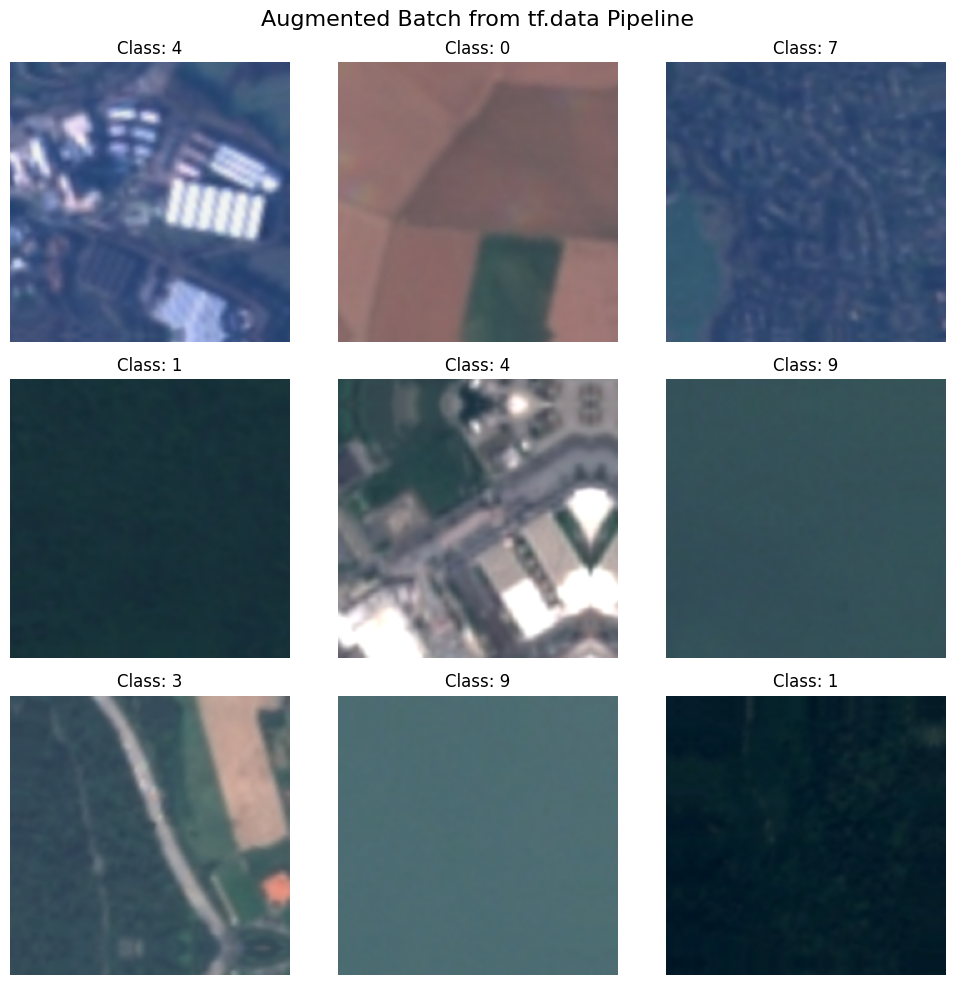

In [12]:
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        img = images[i].numpy().astype("uint8")
        
        plt.imshow(img)
        plt.title(f"Class: {labels[i].numpy()}")
        plt.axis("off")
        
    plt.suptitle("Augmented Batch from tf.data Pipeline", fontsize=16)
    plt.tight_layout()
    plt.show()

## Model Implementation:

In [13]:
base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3),
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Model Train Phase 1:

In [14]:
base.trainable = False

In [15]:
inputs = tf.keras.Input(shape = (224, 224, 3)) # input layer
x = base(inputs, training = False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256,activation="relu")(x)
x = tf.keras.layers.Dropout(0.4)(x)
outputs = tf.keras.layers.Dense(10, activation = "softmax")(x) # output layer

model = tf.keras.Model(inputs, outputs)

In [16]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [17]:
history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs = 10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True) # stops after 3 epochs of no improvements and returns the best_weights
    ]
    
)

Epoch 1/10


I0000 00:00:1771605108.545831      67 service.cc:152] XLA service 0x7c0b68498e20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771605108.545871      67 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771605108.545878      67 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771605110.919532      67 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-20 16:31:57.839941: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 16:31:57.983744: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 16:31:58.321750: E external/local_xl

590/591 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.8080 - loss: 0.5726

2026-02-20 16:35:05.035179: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 16:35:05.176147: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 16:35:05.499324: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 16:35:05.640357: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 16:35:06.363387: E external/local_xla/xla/stream_

591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.8081 - loss: 0.5723

2026-02-20 16:35:37.790935: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 16:35:37.932679: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 16:35:38.260549: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 16:35:38.401816: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 16:35:39.124906: E external/local_xla/xla/stream_

591/591 ━━━━━━━━━━━━━━━━━━━━ 244s 367ms/step - accuracy: 0.8082 - loss: 0.5719 - val_accuracy: 0.9361 - val_loss: 0.1860
Epoch 2/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 27s 46ms/step - accuracy: 0.9183 - loss: 0.2403 - val_accuracy: 0.9426 - val_loss: 0.1768
Epoch 3/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 27s 46ms/step - accuracy: 0.9312 - loss: 0.2066 - val_accuracy: 0.9356 - val_loss: 0.1855
Epoch 4/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 27s 46ms/step - accuracy: 0.9361 - loss: 0.1871 - val_accuracy: 0.9433 - val_loss: 0.1708
Epoch 5/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.9419 - loss: 0.1666 - val_accuracy: 0.9500 - val_loss: 0.1578
Epoch 6/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.9468 - loss: 0.1552 - val_accuracy: 0.9476 - val_loss: 0.1585
Epoch 7/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.9501 - loss: 0.1476 - val_accuracy: 0.9428 - val_loss: 0.1716
Epoch 8/10
591/591 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.9542 - loss: 0.1330 - val_accur

---
### Model Train Phase 2:

In [18]:
base.trainable = True

# Keep early layers frozen
for layer in base.layers[:101]:
    layer.trainable = False

In [19]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-4), # increased the lr because there's no need for major changes in the parameters, it's just small nudges to avoid overshooting.
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

In [20]:
history_phase2 = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 50,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True) # patience increased to match the increased no. of epochs for phase 2
    ]
)

Epoch 1/50


2026-02-20 16:39:28.314621: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 16:39:28.466635: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


590/591 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8333 - loss: 0.5947

2026-02-20 16:40:35.175041: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 16:40:35.319228: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 16:40:36.085214: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 16:40:36.225552: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


591/591 ━━━━━━━━━━━━━━━━━━━━ 133s 142ms/step - accuracy: 0.8336 - loss: 0.5939 - val_accuracy: 0.9611 - val_loss: 0.1247
Epoch 2/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 49s 83ms/step - accuracy: 0.9615 - loss: 0.1178 - val_accuracy: 0.9665 - val_loss: 0.1115
Epoch 3/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 50s 84ms/step - accuracy: 0.9799 - loss: 0.0583 - val_accuracy: 0.9711 - val_loss: 0.1053
Epoch 4/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 50s 85ms/step - accuracy: 0.9868 - loss: 0.0391 - val_accuracy: 0.9681 - val_loss: 0.1106
Epoch 5/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 50s 85ms/step - accuracy: 0.9905 - loss: 0.0308 - val_accuracy: 0.9728 - val_loss: 0.1038
Epoch 6/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 50s 85ms/step - accuracy: 0.9931 - loss: 0.0241 - val_accuracy: 0.9733 - val_loss: 0.1155
Epoch 7/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 50s 85ms/step - accuracy: 0.9924 - loss: 0.0228 - val_accuracy: 0.9681 - val_loss: 0.1271
Epoch 8/50
591/591 ━━━━━━━━━━━━━━━━━━━━ 50s 85ms/step - accuracy: 0.9928 - loss: 0.0220 - val_accur

## Evaluating the model with the test set:

In [21]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Accuracy: {test_acc*100:.2f}%")

84/85 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9763 - loss: 0.1163

2026-02-20 16:53:06.171351: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 16:53:06.309375: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 16:53:06.626387: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 16:53:06.767613: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 16:53:07.482306: E external/local_xla/xla/stream_

85/85 ━━━━━━━━━━━━━━━━━━━━ 16s 185ms/step - accuracy: 0.9763 - loss: 0.1158
Test Accuracy: 97.63%


# Prediction and Plots

In [22]:
def plot_learning_curves(train_costs, val_costs, train_acc, val_acc, save_path=None):
    """
    Plots Cost and Accuracy in side-by-side subplots.
    Handles both lists (history) and scalars (final values) for accuracy.
    """
    fig, ax = plt.subplots(1, 2, figsize=(15, 5))

    # --- Subplot 1: Cost (Loss) ---
    ax[0].plot([float(c) for c in train_costs], label='train')
    ax[0].plot([float(c) for c in val_costs], label='validation')
    ax[0].set_xlabel('Epochs')
    ax[0].set_ylabel('Cost')
    ax[0].set_title('Cost vs Epoch')
    ax[0].legend()

    # --- Subplot 2: Accuracy ---
    
    def is_sequence(x):
        if isinstance(x, list):
            return True
        if isinstance(x, np.ndarray):
            return x.ndim > 0  
        return False

    # Plot Train Accuracy
    if is_sequence(train_acc):
        ax[1].plot([float(c) for c in train_acc], label='train')
    else:
        ax[1].axhline(y=float(train_acc), color='tab:blue', label=f'Final Train Acc: {float(train_acc):.2f}%')

    # Plot Validation Accuracy
    if is_sequence(val_acc):
        ax[1].plot([float(c) for c in val_acc], label='validation')
    else:
        ax[1].axhline(y=float(val_acc), color='tab:orange', linestyle='--', label=f'Final Val Acc: {float(val_acc):.2f}%')
    ax[1].set_ylim([0, 100])
    ax[1].set_xlabel('Epochs')
    ax[1].set_ylabel('Accuracy (%)')
    ax[1].set_title('Accuracy vs Epoch')
    ax[1].legend()

    if save_path:
        plt.savefig(save_path + 'loss_accuracy_curve.png')

    plt.tight_layout()
    plt.show()

In [23]:
def plot_euro_sat_confusion_matrix(y_true, y_pred):
    class_names = [
        "AnnualCrop", "Forest", "HerbaceousVeg", "Highway", "Industrial",
        "Pasture", "PermanentCrop", "Residential", "River", "SeaLake"
    ]
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: EuroSAT Classes')
    plt.show()

In [24]:
test_preds = model.predict(test_ds).argmax(axis=1)

85/85 ━━━━━━━━━━━━━━━━━━━━ 16s 113ms/step


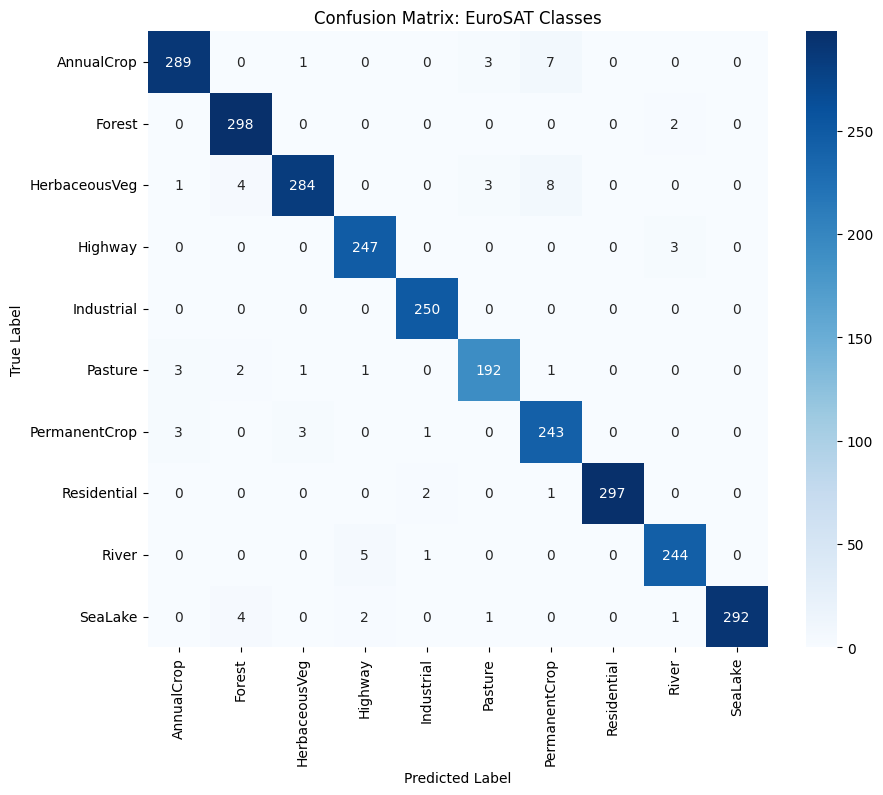

In [25]:
plot_euro_sat_confusion_matrix(y_test, test_preds)

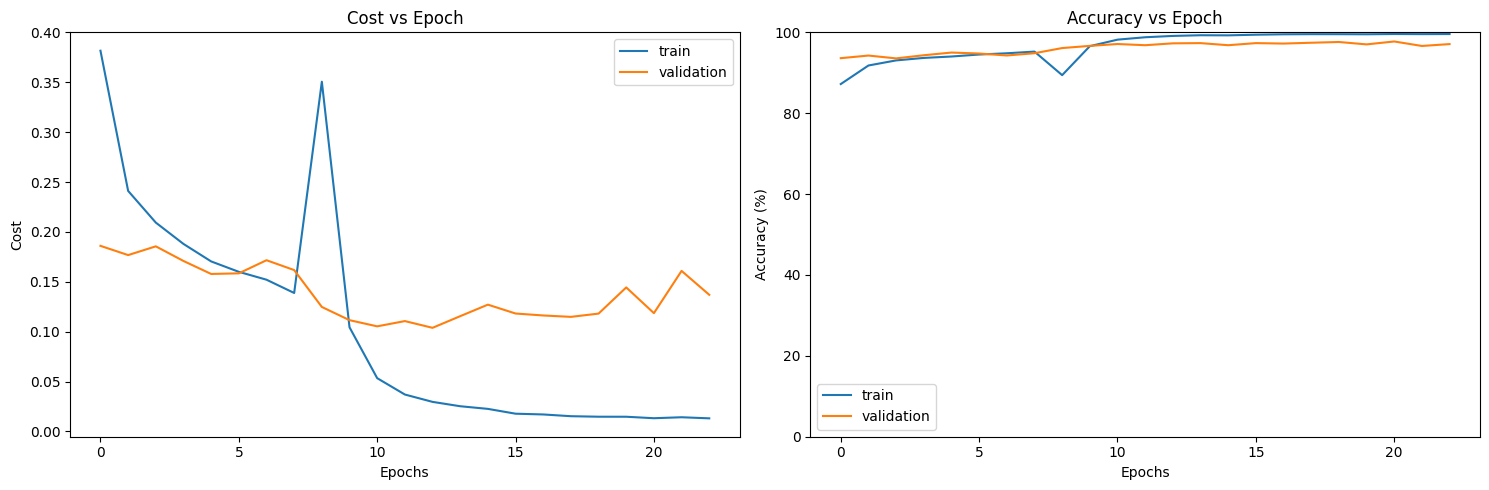

In [26]:
# Combine both phases
train_loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']
train_acc = [x*100 for x in history_phase1.history['accuracy'] + history_phase2.history['accuracy']]
val_acc = [x*100 for x in history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']]

plot_learning_curves(train_loss, val_loss, train_acc, val_acc)

----
# Visualizing what the model learned using Grad-CAM

2026-02-20 16:53:43.021472: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 16:53:43.157167: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 16:53:43.867258: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 16:53:44.002556: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


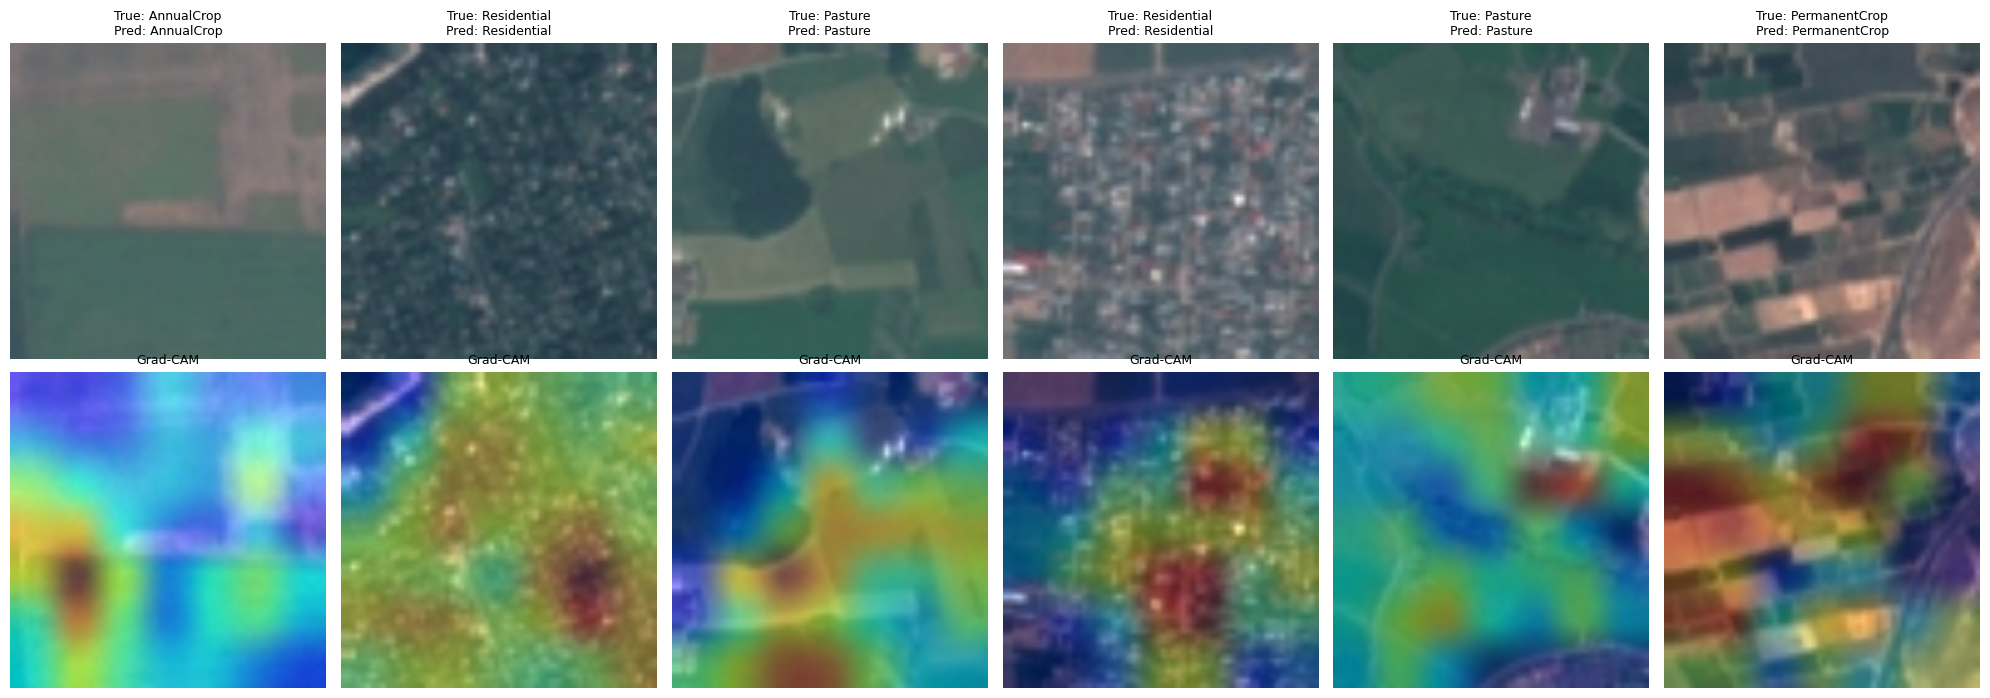

In [27]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generate Grad-CAM heatmap for a single image.
    
    img_array: preprocessed image (1, 224, 224, 3)
    model: your trained model
    last_conv_layer_name: name of the last conv layer (e.g., "top_conv")
    pred_index: which class to compute gradients for (None = predicted class)
    """
    # 1. Get the backbone (EfficientNetB0) from your main model
    backbone = model.get_layer('efficientnetb0')
    
    # 2. Create a sub-model that outputs the last conv layer AND the backbone's output
    grad_model_backbone = tf.keras.models.Model(
        inputs=[backbone.inputs],
        outputs=[backbone.get_layer(last_conv_layer_name).output, backbone.output]
    )

    # 3. Create a classifier model for the rest (pooling + dropout + dense)
    # We reconstruct the head by iterating over layers AFTER the backbone
    classifier_input = tf.keras.Input(shape=backbone.output.shape[1:])
    x = classifier_input
    
    # Find the index of the backbone and iterate through the layers after it
    backbone_idx = [i for i, layer in enumerate(model.layers) if layer.name == 'efficientnetb0'][0]
    for layer in model.layers[backbone_idx + 1:]:
        x = layer(x)
        
    classifier_model = tf.keras.models.Model(inputs=classifier_input, outputs=x)
    
    with tf.GradientTape() as tape:
        # Forward pass through the backbone part
        conv_outputs, backbone_out = grad_model_backbone(img_array)
        
        # Forward pass through the classifier part
        predictions = classifier_model(backbone_out)
        
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    
    grads = tape.gradient(class_channel, conv_outputs)
    
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


def display_gradcam(img, heatmap, alpha=0.4):
    """
    Overlay heatmap on original image.
    
    img: original image as numpy array (224, 224, 3), values 0-255
    heatmap: Grad-CAM heatmap (H, W) normalized to [0, 1]
    alpha: transparency of overlay
    """
    heatmap = np.uint8(255 * heatmap)
    
    jet = plt.cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    
    # Create RGB heatmap image
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)
    
    # Superimpose heatmap on original image
    superimposed_img = jet_heatmap * alpha + img
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)
    
    return superimposed_img


# Usage example
def visualize_gradcam_on_samples(model, dataset, class_names, num_samples=6):
    """
    Show Grad-CAM for multiple test samples.
    """
    
    last_conv_layer_name = "top_conv"
    
    # Get a batch from dataset
    images, labels = next(iter(dataset))
    
    fig, axes = plt.subplots(2, num_samples, figsize=(20, 7))
    
    for i in range(num_samples):
        img = images[i].numpy()
        img_array = np.expand_dims(img, axis=0)  # (1, 224, 224, 3)
        
        preds = model.predict(img_array, verbose=0)
        pred_class = np.argmax(preds[0])
        true_class = labels[i].numpy()
        
        heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)
        
        # Display original
        axes[0, i].imshow(img.astype('uint8'))
        axes[0, i].set_title(f"True: {class_names[true_class]}\nPred: {class_names[pred_class]}", 
                            fontsize=9)
        axes[0, i].axis('off')
        
        # Display Grad-CAM
        cam_img = display_gradcam(img, heatmap)
        axes[1, i].imshow(cam_img)
        axes[1, i].set_title("Grad-CAM", fontsize=9)
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.savefig('gradcam_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()


# Run it
CLASS_NAMES = [
    "AnnualCrop", "Forest", "HerbaceousVegetation", "Highway", "Industrial",
    "Pasture", "PermanentCrop", "Residential", "River", "SeaLake"
]

visualize_gradcam_on_samples(model, test_ds, CLASS_NAMES, num_samples=6)